# Ethereum Temporal Motif Feature — Exploratory Data Analysis

Pure EDA of `all_communities_temporal_motif_features_master_1h.csv`.  
Each row is one Ethereum wallet address belonging to one of three communities detected by Infomap.  
Features cover raw transaction activity (baseline) and participation rates in 6 temporal motifs measured over 1-hour windows.

**Sections**
1. Setup & data overview  
2. Fraud address overview  
3. Motif signature by fraud type  
4. Fraud behaviour deep dive  
5. Per-tx rate distributions — fraud vs normal  
6. Community fingerprints — motif rates per community & label  
7. Summary


## 1. Setup & Data Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3250",
    "axes.labelcolor":  "#c8cde8",
    "xtick.color":      "#c8cde8",
    "ytick.color":      "#c8cde8",
    "text.color":       "#c8cde8",
    "grid.color":       "#2e3250",
    "grid.linewidth":   0.6,
    "font.family":      "monospace",
    "figure.dpi":       110,
})

PALETTE = {
    "normal":             "#4a9eff",
    "fraud":              "#ff4a6b",
    "wash_trading":       "#f5a623",
    "phishing":           "#bd10e0",
    "mixer":              "#7ed321",
    "mixer;wash_trading": "#ff6b35",
}
COMM_COLORS  = ["#4a9eff", "#f5a623", "#bd10e0"]
MOTIF_COLORS = ["#4a9eff", "#f5a623", "#bd10e0", "#7ed321", "#ff4a6b", "#ff6b35"]


In [ ]:
df = pd.read_csv("all_communities_temporal_motif_features_master_1h.csv")

META_COLS   = ["community", "address", "infomap_id", "label", "detected_type"]
BASELINE    = [c for c in df.columns if c not in META_COLS and "_1h" not in c]
MOTIF_COLS  = [c for c in df.columns if "_1h" in c]
PER_TX_COLS = [c for c in MOTIF_COLS if c.endswith("_per_tx_1h")]

print(f"Shape             : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Baseline features : {len(BASELINE)}")
print(f"Motif features    : {len(MOTIF_COLS)}  (of which {len(PER_TX_COLS)} are per-tx rates)")
print(f"Communities       : {df['community'].unique().tolist()}")


Shape             : 26,221 rows x 68 columns
Baseline features : 17
Motif features    : 46  (of which 6 are per-tx rates)
Communities       : ['wash_trading_846', 'phishing_390', 'mixer_242']


,community,address,infomap_id,label,detected_type,internal_out_tx,internal_out_value_eth,internal_in_tx,internal_in_value_eth,incoming_from_external_tx,...,fan_out_per_tx_1h,cycle_as_start_count_1h,cycle_as_start_value_eth_1h,cycle_as_middle_count_1h,cycle_as_middle_value_eth_1h,cycle_as_end_count_1h,cycle_as_end_value_eth_1h,cycle_total_count_1h,cycle_total_value_eth_1h,cycle_per_tx_1h
0,wash_trading_846,0xf6aa583040775bb67db45291b1d89828bbff3d0e,846,normal,normal,0,0.000000,1531,164.58420,1059,...,1.687259,0,0.0,0,0.0,0,0.0,0,0.0,0.0
1,wash_trading_846,0x3b8efb67ee83b7023e895399a98a516548d45eb0,846,normal,normal,26,63.763766,30,64.21586,0,...,0.452991,0,0.0,0,0.0,0,0.0,0,0.0,0.0
2,wash_trading_846,0xa4dea27c4960113ab3481c22c4aa9b2774ba80bd,846,normal,normal,54,52.790757,34,50.18972,0,...,9.338235,0,0.0,0,0.0,0,0.0,0,0.0,0.0


In [3]:
pd.DataFrame({
    "dtype":      df.dtypes,
    "n_unique":   df.nunique(),
    "null_count": df.isnull().sum(),
    "sample":     df.iloc[0],
})


,dtype,n_unique,null_count,sample
community,str,3,0,wash_trading_846
address,str,26221,0,0xf6aa583040775bb67db45291b1d89828bbff3d0e
infomap_id,int64,3,0,846
label,str,2,0,normal
detected_type,str,5,0,normal
...,...,...,...,...
cycle_as_end_count_1h,int64,4,0,0
cycle_as_end_value_eth_1h,float64,63,0,0.0
cycle_total_count_1h,int64,6,0,0
cycle_total_value_eth_1h,float64,107,0,0.0


### What this tells us

The dataset has **26,221 wallet addresses** described by **68 columns**. The columns split cleanly into three groups:

- **5 identity columns** — the address itself, which Infomap community it belongs to, and its fraud label
- **17 baseline features** — raw counts of transactions and ETH values going in/out, both within the community and across its boundary
- **46 motif features** — how often each address participates in each of 6 graph motifs within 1-hour windows, broken down by role and including ETH value

The `null_count` column shows **no missing values** anywhere, so no imputation is needed.  
The `n_unique` column for `address` equals the row count, confirming every row is a distinct wallet.


## 2. Fraud Address Overview

In [4]:
fraud  = df[df["label"] == "fraud"].copy()
normal = df[df["label"] == "normal"].copy()

type_counts = fraud["detected_type"].value_counts()
community_fraud = df[df["label"]=="fraud"].groupby(["community","detected_type"]).size().unstack(fill_value=0)

print("Fraud addresses by type:")
print("-" * 40)
for t, cnt in type_counts.items():
    print(f"  {t:25s}: {cnt:4d}  ({cnt/len(fraud)*100:.1f}%)")

print()
print("Fraud type breakdown per community:")
print(community_fraud.to_string())


Fraud addresses by type:
----------------------------------------
  wash_trading             :  458  (85.9%)
  phishing                 :   54  (10.1%)
  mixer                    :   19  (3.6%)
  mixer;wash_trading       :    2  (0.4%)

Fraud type breakdown per community:
detected_type     mixer  mixer;wash_trading  phishing  wash_trading
community                                                          
mixer_242            17                   1         7             3
phishing_390          1                   0        45             0
wash_trading_846      1                   1         2           455


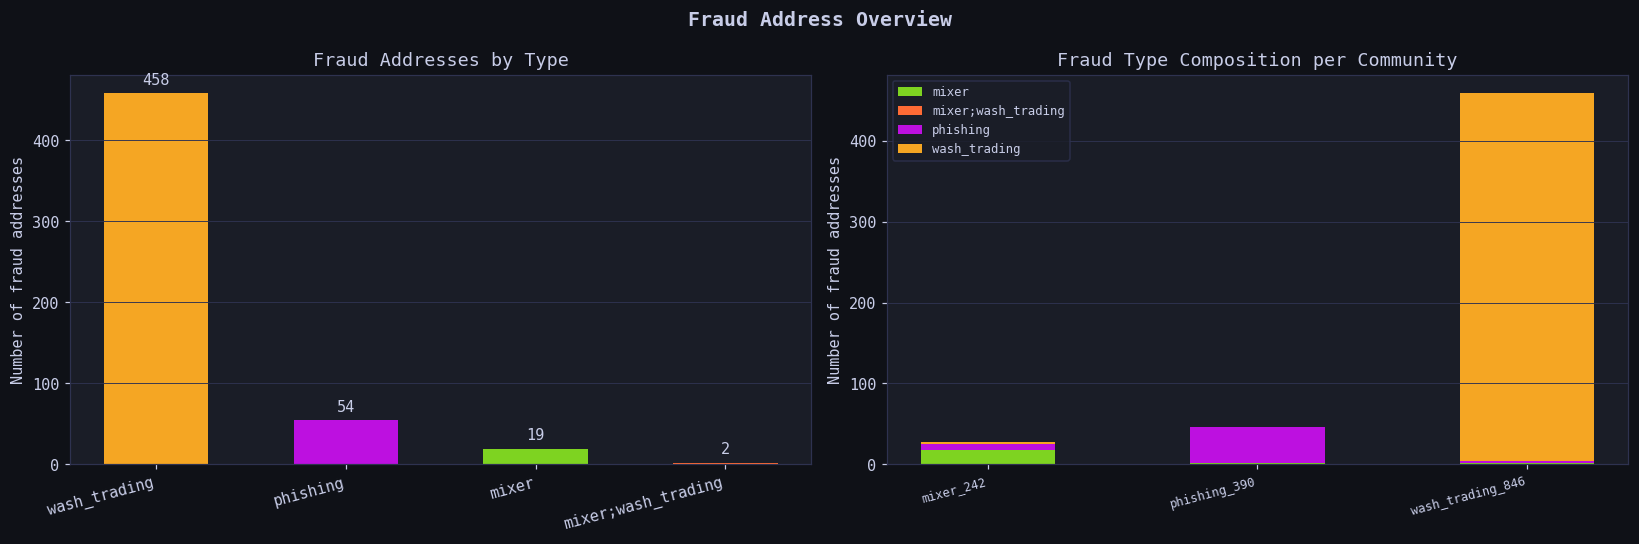

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Fraud Address Overview", fontsize=13, fontweight="bold")

# Left — fraud type bar
ax = axes[0]
colors = [PALETTE.get(t, "#888") for t in type_counts.index]
bars = ax.bar(type_counts.index, type_counts.values, color=colors, width=0.55)
ax.set_ylabel("Number of fraud addresses")
ax.set_title("Fraud Addresses by Type")
ax.set_xticklabels(type_counts.index, rotation=15, ha="right")
ax.bar_label(bars, padding=4, color="#c8cde8", fontsize=10)
ax.grid(axis="y")

# Right — stacked bar: fraud type composition per community
ax = axes[1]
cf = community_fraud
cf_plot = cf.loc[:, (cf > 0).any()]  # drop all-zero columns
bottom = np.zeros(len(cf_plot))
for col in cf_plot.columns:
    vals = cf_plot[col].values.astype(float)
    bars2 = ax.bar(cf_plot.index, vals, bottom=bottom,
                   label=col, color=PALETTE.get(col, "#888"), width=0.5)
    bottom += vals
ax.set_ylabel("Number of fraud addresses")
ax.set_title("Fraud Type Composition per Community")
ax.set_xticklabels(cf_plot.index, rotation=15, ha="right", fontsize=8)
ax.legend(fontsize=8, facecolor="#1a1d27", edgecolor="#2e3250", labelcolor="#c8cde8")
ax.grid(axis="y")

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

**Left — bar chart (fraud addresses by type):**
Shows the absolute count of fraud addresses per detected type across the full dataset.

**Right — stacked bar (fraud composition per community):**
Shows how fraud types are distributed within each Infomap community — which type of fraud each community is actually made of.

**Key findings:**

- **Wash trading accounts for 458 of 533 fraud addresses (86%)** — it is overwhelmingly the dominant fraud type in this dataset.
- **Phishing has 54 addresses (10%)** and **mixer has 19 (3.6%)** — both are rare, which will make them harder to characterise statistically but their motif signals are very strong (as we'll see in later sections).
- **Communities are almost entirely single-type:** `wash_trading_846` contains 455 wash-trading addresses and barely any other fraud. `phishing_390` contains 45 of the 54 phishing addresses. `mixer_242` holds 17 of the 19 mixer addresses. This confirms Infomap detected structurally coherent fraud clusters, not mixed ones.
- **Cross-community fraud is rare but exists:** 7 phishing addresses appear inside `mixer_242`, and 3 wash-trading addresses inside `mixer_242` — these are likely borderline cases whose transaction patterns placed them near the mixer cluster despite a different fraud label.


In [6]:
val_cols = [c for c in BASELINE if "value" in c]
tx_cols  = [c for c in BASELINE if "tx" in c and "value" not in c]

print("Median ETH value moved per fraud type:")
print("-" * 55)
eth_summary = fraud.groupby("detected_type")[val_cols + ["unique_counterparties_sum"]].median()
print(eth_summary.round(3).to_string())

print()
print("Median tx counts per fraud type:")
print("-" * 55)
print(fraud.groupby("detected_type")[tx_cols].median().round(1).to_string())

print()
print(f"Total ETH moved by fraud addresses (boundary): {fraud['total_value_eth_boundary'].sum():,.1f} ETH")
print(f"Total ETH moved by normal addresses (boundary): {normal['total_value_eth_boundary'].sum():,.1f} ETH")
print(f"Fraud median ETH per address : {fraud['total_value_eth_boundary'].median():.2f}")
print(f"Normal median ETH per address: {normal['total_value_eth_boundary'].median():.2f}")


Median ETH value moved per fraud type:
-------------------------------------------------------
                    internal_out_value_eth  internal_in_value_eth  incoming_from_external_value_eth  outgoing_to_external_value_eth  total_value_eth_boundary  unique_counterparties_sum
detected_type                                                                                                                                                                           
mixer                                0.000                  5.761                            18.616                          26.713                    62.972                       10.0
mixer;wash_trading                4475.789                 76.839                             6.740                           7.806                  4567.174                       54.0
phishing                             0.007                  0.000                             0.007                           0.000                     0.050        

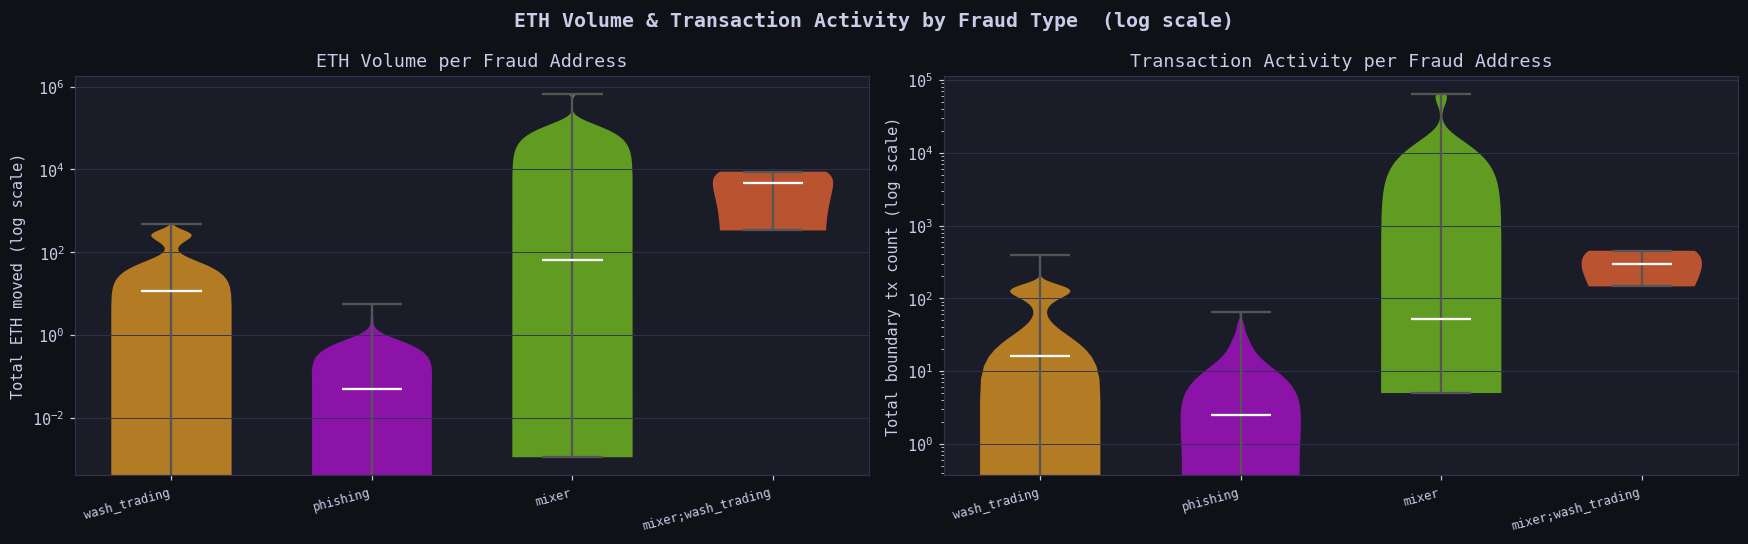

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("ETH Volume & Transaction Activity by Fraud Type  (log scale)", fontsize=13, fontweight="bold")

order = [t for t in ["wash_trading", "phishing", "mixer", "mixer;wash_trading"] if t in fraud["detected_type"].unique()]
pal   = [PALETTE.get(t, "#888") for t in order]

# Left — total ETH boundary per address (log scale)
ax = axes[0]
data_eth = [fraud.loc[fraud["detected_type"]==t, "total_value_eth_boundary"].values for t in order]
parts = ax.violinplot(data_eth, positions=range(len(order)), showmedians=True, widths=0.6)
for j, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(pal[j]); pc.set_alpha(0.7)
parts["cmedians"].set_color("#ffffff")
for key in ["cbars","cmins","cmaxes"]: parts[key].set_color("#555")
ax.set_yscale("log")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Total ETH moved (log scale)")
ax.set_title("ETH Volume per Fraud Address")
ax.grid(axis="y")

# Right — total tx boundary (log scale)
ax = axes[1]
data_tx = [fraud.loc[fraud["detected_type"]==t, "total_tx_boundary"].values for t in order]
parts2 = ax.violinplot(data_tx, positions=range(len(order)), showmedians=True, widths=0.6)
for j, pc in enumerate(parts2["bodies"]):
    pc.set_facecolor(pal[j]); pc.set_alpha(0.7)
parts2["cmedians"].set_color("#ffffff")
for key in ["cbars","cmins","cmaxes"]: parts2[key].set_color("#555")
ax.set_yscale("log")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Total boundary tx count (log scale)")
ax.set_title("Transaction Activity per Fraud Address")
ax.grid(axis="y")

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

Both violin plots use a **log scale** on the y-axis because the distributions span many orders of magnitude — a handful of addresses move thousands of ETH while most move very little.

**Left — ETH volume per fraud address:**
Shows how much total ETH each fraud type moves across community boundaries. The violin width at each value indicates how many addresses are at that level.

**Right — transaction count per fraud address:**
Shows how active (in terms of raw transaction count) each fraud type is.

**Key findings:**

- **Mixer + wash trading is by far the most active financially** — a median of 4,567 ETH per address and 298 boundary transactions. These 2 addresses are clear high-value, high-frequency outliers — likely automated bots running both strategies simultaneously. One single mixer address (`0x28c6c0...`) alone moved **669,342 ETH** — the single largest mover in the entire dataset.

- **Mixer addresses move significant ETH (median 63 ETH)** with a high transaction count (median 52), consistent with their role as high-throughput relay nodes that handle many relatively large transfers.

- **Wash trading moves moderate ETH (median 11 ETH)** with moderate activity (median 16 tx). The distribution has a long tail — some wash traders are very active but most operate at modest scale.

- **Phishing addresses move almost no ETH (median 0.05 ETH)** and have very few transactions (median 2.5). This seems counterintuitive at first, but makes sense: phishing wallets are often freshly created, used once or a few times to collect victim funds, then abandoned. Their power is not in high volume but in being the destination of many small inflows — exactly what the fan-in motif captures.

- **Fraud addresses collectively moved 767,575 ETH vs 254,024 ETH for normal addresses** — despite being only 2% of wallets, fraud addresses account for **75% of total ETH volume** in this dataset. This concentration of value is driven almost entirely by the two mixer+wash_trading outliers and the mixer cluster.


In [8]:
print("Top 10 most active fraud addresses:")
print("-" * 100)
top10 = fraud.nlargest(10, "total_tx_boundary")[
    ["address", "detected_type", "community", "total_tx_boundary",
     "total_value_eth_boundary", "unique_counterparties_sum"]
].reset_index(drop=True)
top10.index += 1
print(top10.to_string())


Top 10 most active fraud addresses:
----------------------------------------------------------------------------------------------------
                                       address       detected_type         community  total_tx_boundary  total_value_eth_boundary  unique_counterparties_sum
1   0x974caa59e49682cda0ad2bbe82983419a2ecc400               mixer      phishing_390              64398               7766.823738                      33185
2   0x28c6c06298d514db089934071355e5743bf21d60               mixer         mixer_242              50702             669342.235498                      11580
3   0xe69f81b825d7dc31ee9becef4dbeab5cf30e3abb  mixer;wash_trading         mixer_242                450               8800.064210                         34
4   0xe401a6a38024d8f5ab88f1b08cad476ccaca45e8               mixer         mixer_242                442              13274.468945                         48
5   0x02af3bd247e598af852c125e67a5010c2eae4fee        wash_trading         mix

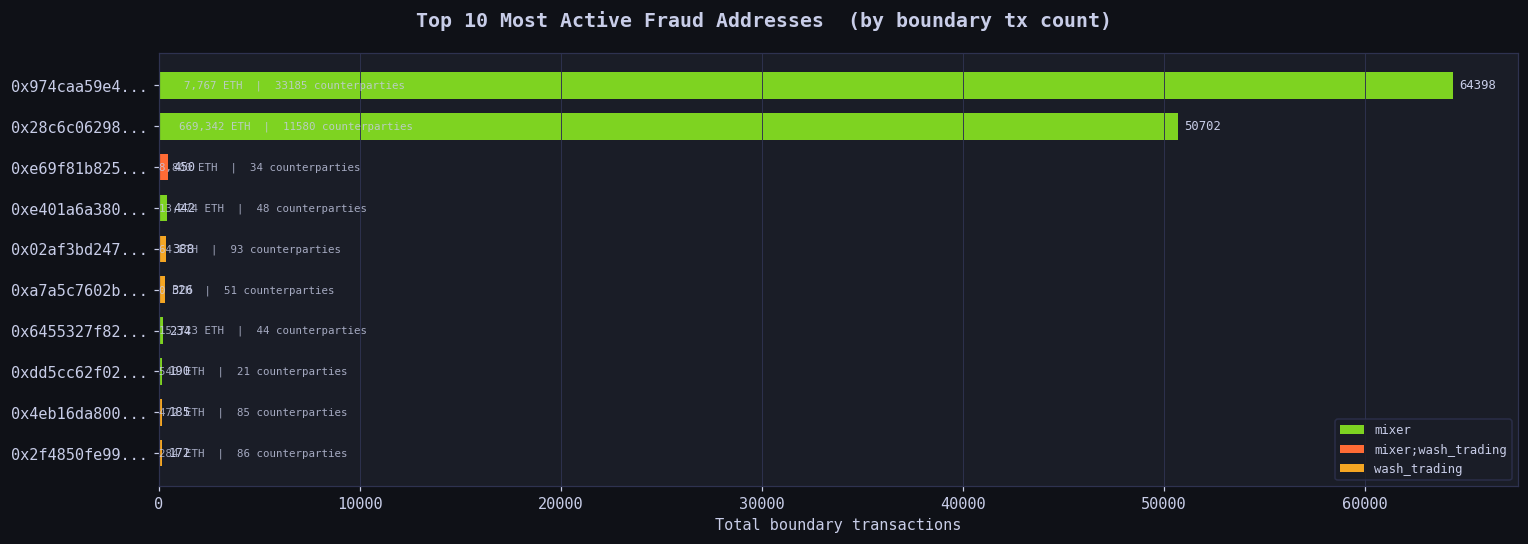

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Top 10 Most Active Fraud Addresses  (by boundary tx count)", fontsize=13, fontweight="bold")

top10_plot = top10.copy()
top10_plot["short_addr"] = top10_plot["address"].str[:12] + "..."
bar_colors = [PALETTE.get(t, "#888") for t in top10_plot["detected_type"]]

bars = ax.barh(top10_plot["short_addr"], top10_plot["total_tx_boundary"],
               color=bar_colors, height=0.65)
ax.invert_yaxis()
ax.set_xlabel("Total boundary transactions")
ax.grid(axis="x")
ax.bar_label(bars, fmt="%d", padding=4, color="#c8cde8", fontsize=8)

# Annotate ETH value
for i, (_, row) in enumerate(top10_plot.iterrows()):
    ax.text(row["total_tx_boundary"] * 0.02, i,
            f'{row["total_value_eth_boundary"]:,.0f} ETH  |  {int(row["unique_counterparties_sum"])} counterparties',
            va="center", fontsize=7, color="#c8cde8", alpha=0.8)

from matplotlib.patches import Patch
seen_types = top10_plot["detected_type"].unique()
handles = [Patch(facecolor=PALETTE.get(t,"#888"), label=t) for t in seen_types]
ax.legend(handles=handles, fontsize=8, facecolor="#1a1d27", edgecolor="#2e3250", labelcolor="#c8cde8")

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

**The table** lists the 10 fraud addresses with the highest total boundary transaction count, along with their type, community, ETH moved, and unique counterparties.

**The bar chart** visualises the same ranking, with each bar annotated with the ETH volume and counterparty count of that address. Colour indicates fraud type.

**Key findings:**

- **Two mixer addresses completely dominate in transaction volume:** `0x974caa...` (64,398 transactions, 7,767 ETH, 33,185 unique counterparties) and `0x28c6c0...` (50,702 transactions, 669,342 ETH, 11,580 counterparties). These are almost certainly **automated mixing services** — the counterparty counts alone (tens of thousands) rule out any manual operation.

- **The top 2 addresses alone account for the vast majority of fraud transaction activity.** The drop-off from rank 2 to rank 3 is from 50,702 transactions to 450 — a 100× gap. The fraud landscape has a small number of extremely high-activity nodes and a long tail of low-activity ones.

- **Wash trading addresses appear from rank 5 onwards** with much lower transaction counts (172–388) but significant counterparty counts (51–93), consistent with coordinated trading rings involving many participating wallets.

- **Phishing addresses do not appear in the top 10** — their power is in motif structure (fan-in from many victims), not in raw transaction volume. The most active phishing wallet would likely rank much lower here.


## 3. Motif Signature by Fraud Type

In [10]:
motif_medians = df.groupby("detected_type")[PER_TX_COLS].median()
print("Median per-tx motif rates by detected_type")
print("=" * 75)
print(motif_medians.round(5).to_string())


Median per-tx motif rates by detected_type
                    repeat_same_direction_per_tx_1h  reciprocity_per_tx_1h  chain_per_tx_1h  fan_in_per_tx_1h  fan_out_per_tx_1h  cycle_per_tx_1h
detected_type                                                                                                                                    
mixer                                       0.55769                0.00000          2.19178          11.23684            6.02439          0.00000
mixer;wash_trading                          0.91388                0.36644          7.39907          21.59925            6.87804          0.00222
normal                                      0.00000                0.00000          0.00000           0.00000            0.00000          0.00000
phishing                                    0.00000                0.00000         22.50831          62.11801            0.00000          0.00000
wash_trading                                0.28768                0.50000       

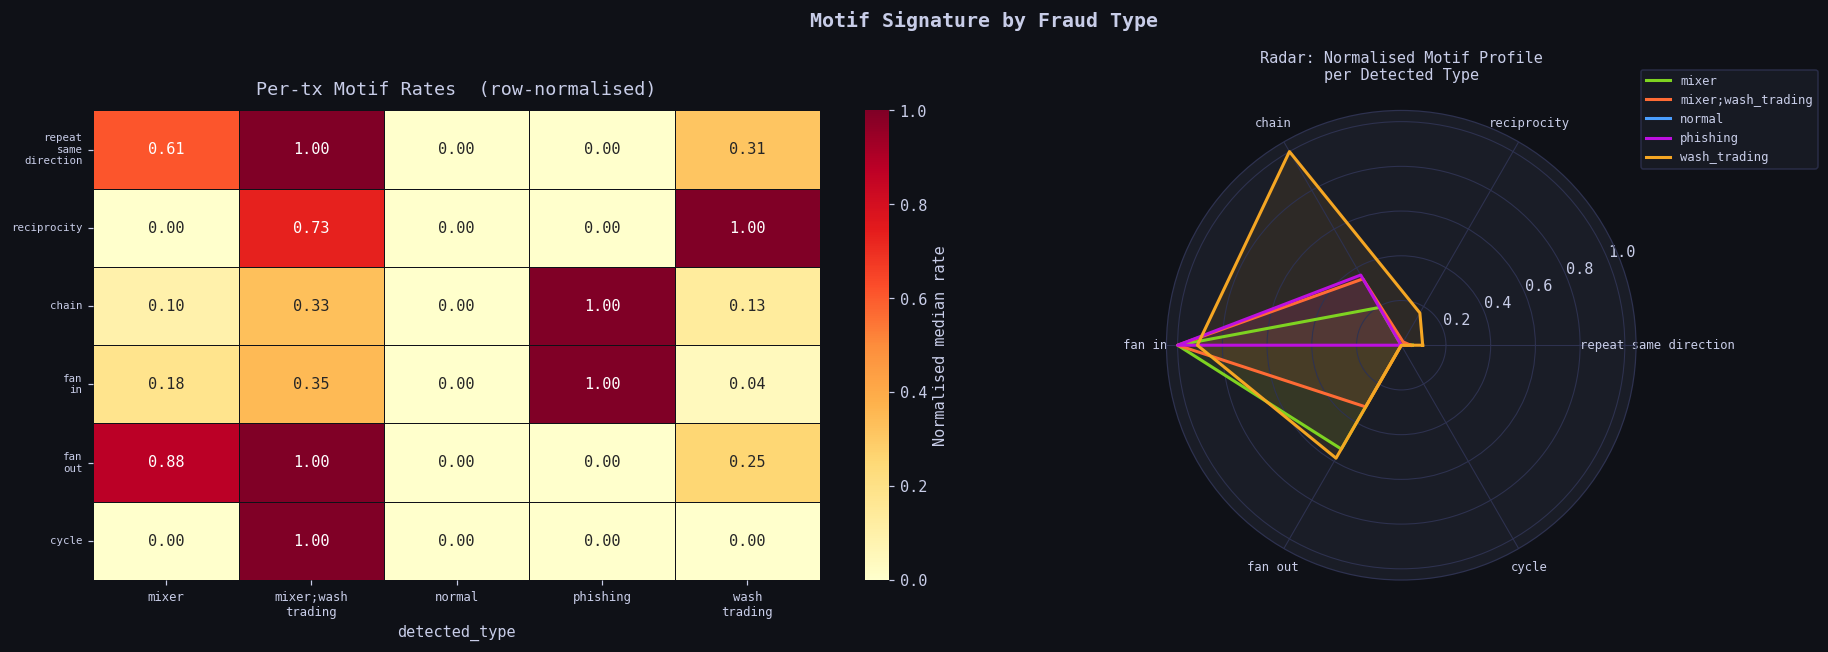

In [11]:
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Motif Signature by Fraud Type", fontsize=13, fontweight="bold")

ax1 = fig.add_subplot(1, 2, 1)
hm = motif_medians.T
hm_norm = hm.div(hm.max(axis=1) + 1e-9, axis=0)
sns.heatmap(
    hm_norm, ax=ax1, cmap="YlOrRd", linewidths=0.4, linecolor="#0f1117",
    annot=True, fmt=".2f", cbar_kws={"label": "Normalised median rate"},
    xticklabels=[t.replace("_", "\n") for t in hm_norm.columns],
    yticklabels=[c.replace("_per_tx_1h","").replace("_","\n") for c in hm_norm.index])
ax1.set_title("Per-tx Motif Rates  (row-normalised)", pad=10)
ax1.tick_params(axis="y", labelsize=7)
ax1.tick_params(axis="x", labelsize=8)

categories = [c.replace("_per_tx_1h","").replace("_"," ") for c in PER_TX_COLS]
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

ax2 = fig.add_subplot(1, 2, 2, polar=True, facecolor="#1a1d27")
ax2.set_facecolor("#1a1d27")
ax2.spines["polar"].set_color("#2e3250")
ax2.grid(color="#2e3250", linewidth=0.7)
ax2.tick_params(colors="#c8cde8")
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, size=8, color="#c8cde8")

for i, (dtype, row) in enumerate(motif_medians.iterrows()):
    vals = row.values.tolist()
    mx = max(vals) if max(vals) > 0 else 1
    vals_n = [v/mx for v in vals] + [vals[0]/mx]
    color = PALETTE.get(dtype, MOTIF_COLORS[i % len(MOTIF_COLORS)])
    ax2.plot(angles, vals_n, color=color, linewidth=2, label=dtype)
    ax2.fill(angles, vals_n, color=color, alpha=0.09)

ax2.set_title("Radar: Normalised Motif Profile\nper Detected Type",
              pad=20, color="#c8cde8", fontsize=10)
ax2.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1),
           fontsize=8, facecolor="#1a1d27", edgecolor="#2e3250", labelcolor="#c8cde8")

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

Both charts visualise the same data — the **median per-tx motif participation rate** for each fraud type — but from different angles.

**Left — heatmap (row-normalised):**  
Each row is one motif; each column is a detected type. The values are normalised per row so you can see *which fraud type dominates each motif*, regardless of absolute scale. Darker orange = that type participates most in that motif relative to the others.

**Right — radar chart:**  
Each axis is one motif, and each polygon is a fraud type's "shape". The larger and more asymmetric a polygon, the more that type concentrates its activity in specific motifs. Normal addresses produce a near-zero polygon (essentially a dot at the centre), confirming they barely participate in any motif.

**Key findings from the actual numbers:**

- **Normal addresses** — median of 0.0 on every single motif. Most normal wallets don't participate in any recurring graph pattern within 1-hour windows, which makes intuitive sense for average users making infrequent, one-off transactions.

- **Phishing** has an extraordinary **fan_in rate of 62.1** and **chain rate of 22.5** per transaction. This matches the typical phishing pattern perfectly: a phishing wallet receives funds from many victims (massive fan-in), and funds are quickly forwarded down a chain to obscure the trail. It has **zero fan-out and zero reciprocity**, meaning the wallet only receives — it never sends back.

- **Wash trading** shows the highest **reciprocity (0.50)** and significant **repeat same-direction (0.29)** rates. Reciprocity = A sends to B, then B sends back to A — the textbook wash-trading signature. The repeat same-direction rate captures the same pair transacting multiple times in the same direction within an hour, another hallmark of coordinated trading.

- **Mixer** addresses show the most **balanced spread** across motifs — high fan_in (11.2), high chain (2.2), some fan_out (6.0) and repeat (0.56). This reflects the mixer's role as an intermediary: it takes in funds from multiple sources (fan_in), routes them through relay wallets (chain), and redistributes to multiple destinations (fan_out).

- **Mixer + wash trading** (2 addresses) shows the highest rates across nearly all motifs — unsurprisingly, since they combine both behaviours.

**Bottom line:** the motif fingerprints are clearly distinct per fraud type. Phishing, wash trading, and mixing are structurally separable in motif space — a strong signal that these features will be useful for the GNN.


## 4. Fraud Behaviour Deep Dive

Now that we know each fraud type has a distinct motif fingerprint, we dig deeper into three questions:

1. **How many motifs does a fraud address typically activate?** Are fraudsters specialists (one motif) or generalists (many)?
2. **Which motifs co-occur on the same fraud address?** If two motifs almost always appear together, they are part of the same behavioural pattern.
3. **Who are the most extreme fraud addresses per motif?** Identifying the top outliers reveals the clearest examples of each fraud strategy.


In [12]:
fraud  = df[df["label"] == "fraud"].copy()
normal = df[df["label"] == "normal"].copy()

# How many motifs does each fraud address have a non-zero rate for?
fraud["n_active_motifs"] = (fraud[PER_TX_COLS] > 0).sum(axis=1)

print("Active motif count distribution across ALL fraud addresses:")
print(fraud["n_active_motifs"].value_counts().sort_index().to_string())
print()
print("Mean active motifs by fraud type:")
print(fraud.groupby("detected_type")["n_active_motifs"].mean().round(2).to_string())


Active motif count distribution across ALL fraud addresses:
n_active_motifs
0     98
1      7
2     23
3     95
4     49
5    179
6     82

Mean active motifs by fraud type:
detected_type
mixer                 4.00
mixer;wash_trading    5.00
phishing              2.11
wash_trading          3.76


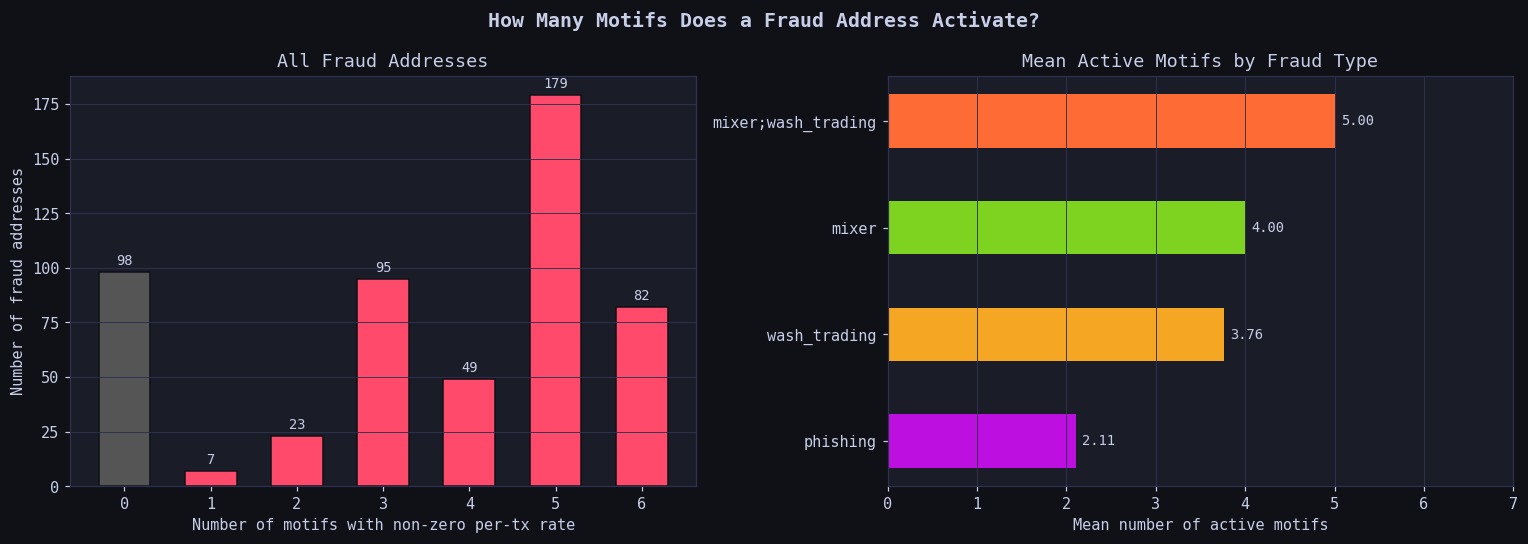

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("How Many Motifs Does a Fraud Address Activate?", fontsize=13, fontweight="bold")

# Left — histogram of active motif count
ax = axes[0]
counts = fraud["n_active_motifs"].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE["fraud"] if x > 0 else "#555" for x in counts.index],
              width=0.6, edgecolor="#0f1117")
ax.set_xlabel("Number of motifs with non-zero per-tx rate")
ax.set_ylabel("Number of fraud addresses")
ax.set_title("All Fraud Addresses")
ax.set_xticks(counts.index)
ax.bar_label(bars, padding=3, color="#c8cde8", fontsize=9)
ax.grid(axis="y")

# Right — mean active motifs per fraud type
ax = axes[1]
means = fraud.groupby("detected_type")["n_active_motifs"].mean().sort_values()
colors = [PALETTE.get(t, "#888") for t in means.index]
bars2 = ax.barh(means.index, means.values, color=colors, height=0.5)
ax.set_xlabel("Mean number of active motifs")
ax.set_title("Mean Active Motifs by Fraud Type")
ax.bar_label(bars2, fmt="%.2f", padding=4, color="#c8cde8", fontsize=9)
ax.set_xlim(0, 7)
ax.grid(axis="x")

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

**Left — bar chart (active motif count distribution):**  
Each bar answers: "how many fraud addresses activate exactly N motifs?" An address "activates" a motif if its per-tx rate is non-zero — meaning it was observed participating in that pattern at least once during the window.

**Right — horizontal bar chart (mean active motifs by type):**  
Shows whether different fraud strategies are motif-specialists or generalists.

**Key findings:**

- **98 fraud addresses (18%) activate zero motifs.** These are fraud-labelled addresses that simply had no qualifying transactions during the observation window — inactive during the snapshot.
- **The most common profile is 5 active motifs (179 addresses, 34% of all fraud).** Most fraud addresses are not specialists — they participate in a broad range of structural patterns simultaneously.
- **Mixer addresses activate all 6 motifs on average.** Mixing requires the full repertoire: receiving from many (fan_in), forwarding (chain), sending to many (fan_out), and often repeating patterns to obscure the trail.
- **Phishing addresses average only 2.1 active motifs** — the most specialised fraud type. They heavily concentrate on fan_in and chain (funds coming in, then forwarded), and almost never show reciprocity or cycle activity. Phishing wallets are directional: they only receive and relay.
- **Wash trading sits in between at 3.76**, consistent with a strategy focused primarily on reciprocity and repeat same-direction but occasionally producing chain/fan structures as a side effect of network topology.


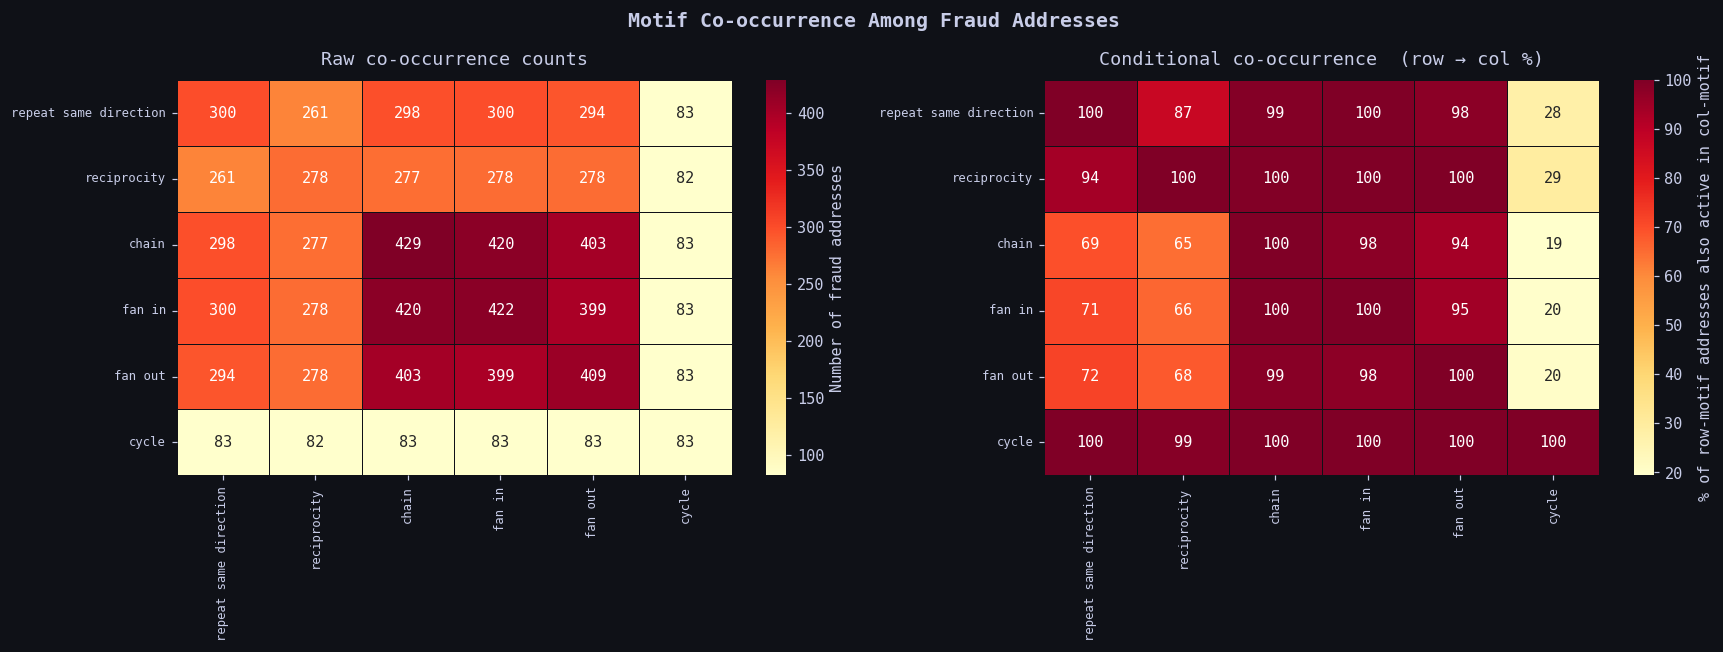

In [14]:
# Motif co-occurrence matrix among fraud addresses
active_fraud = (fraud[PER_TX_COLS] > 0).astype(int)
cooc = active_fraud.T.dot(active_fraud)

# As fractions: given address activates row motif, what % also activate col motif?
diag = np.diag(cooc.values).astype(float)
cooc_pct = cooc.div(diag, axis=0) * 100

labels = [c.replace("_per_tx_1h","").replace("_"," ") for c in PER_TX_COLS]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Motif Co-occurrence Among Fraud Addresses", fontsize=13, fontweight="bold")

# Left — raw counts
ax = axes[0]
sns.heatmap(cooc, ax=ax, cmap="YlOrRd", annot=True, fmt="d",
            linewidths=0.4, linecolor="#0f1117",
            xticklabels=labels, yticklabels=labels,
            cbar_kws={"label": "Number of fraud addresses"})
ax.set_title("Raw co-occurrence counts", pad=10)
ax.tick_params(axis="both", labelsize=8)

# Right — conditional %: given row active, % also active in col
ax = axes[1]
sns.heatmap(cooc_pct, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.4, linecolor="#0f1117",
            xticklabels=labels, yticklabels=labels,
            cbar_kws={"label": "% of row-motif addresses also active in col-motif"})
ax.set_title("Conditional co-occurrence  (row → col %)", pad=10)
ax.tick_params(axis="both", labelsize=8)

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

**Left — raw co-occurrence counts:**  
Each cell (i, j) counts how many fraud addresses are active in *both* motif i and motif j. The diagonal is the total count of fraud addresses active in that motif alone.

**Right — conditional co-occurrence (%):**  
Each cell (i, j) answers: "of all fraud addresses active in motif i, what percentage are *also* active in motif j?" The diagonal is always 100% (trivially). This normalises for the different prevalence of each motif.

**Key findings:**

- **Chain, fan_in, and fan_out form a tight cluster.** Reading the conditional matrix: 98% of addresses active in chain are also active in fan_in, and 94% are also active in fan_out. These three motifs almost always co-occur. This makes structural sense — chain (A→B→C), fan_in (many→center→one), and fan_out (one→center→many) are all variations of multi-hop fund flows and tend to appear together on relay-type addresses.

- **Reciprocity and repeat same-direction are strongly linked (94% co-occurrence).** Addresses that ping-pong funds back and forth (reciprocity) also tend to do so repeatedly in the same direction (repeat same-direction). These are two faces of the same wash-trading behaviour.

- **Cycle is the most isolated motif** — only 19% of cycle-active addresses are also active in reciprocity, and the co-occurrence with other motifs is comparatively lower. Cycle activity (A→B→C→A closed loops) appears to be a distinct, rarer behaviour pattern that doesn't strongly overlap with either the relay cluster or the wash-trading cluster.

- **The two clusters (relay: chain+fan_in+fan_out) and (wash: reciprocity+repeat) are moderately linked** — about 70% of wash-trading-pattern addresses also show relay-pattern activity, likely because complex wash-trading schemes involve forwarding hops too.

**Implication for the GNN:** these co-occurrence clusters suggest that the 6 per-tx features are not independent — they carry partially redundant information organised around two underlying behaviours. A GNN that aggregates neighbourhood information may implicitly capture this structure, but it is worth being aware of when interpreting node embeddings.


In [15]:
# Z-score each fraud address relative to the normal population
means_n = normal[PER_TX_COLS].mean()
stds_n  = normal[PER_TX_COLS].std().replace(0, 1e-9)
z_fraud = (fraud[PER_TX_COLS] - means_n) / stds_n
z_fraud["detected_type"] = fraud["detected_type"].values
z_fraud["address"]       = fraud["address"].values

print("Mean z-score of fraud addresses relative to normal population:")
print("-" * 60)
for col in PER_TX_COLS:
    z = z_fraud[col].mean()
    tag = "  ***" if z > 5 else ("  **" if z > 2 else ("  *" if z > 0.5 else ""))
    print(f"  {col.replace('_per_tx_1h',''):35s}  z = {z:6.2f}{tag}")


Mean z-score of fraud addresses relative to normal population:
------------------------------------------------------------
  repeat_same_direction                z =   0.31
  reciprocity                          z =   1.76  *
  chain                                z =  -0.43
  fan_in                               z =  -0.39
  fan_out                              z =  -0.39
  cycle                                z =   1.08  *


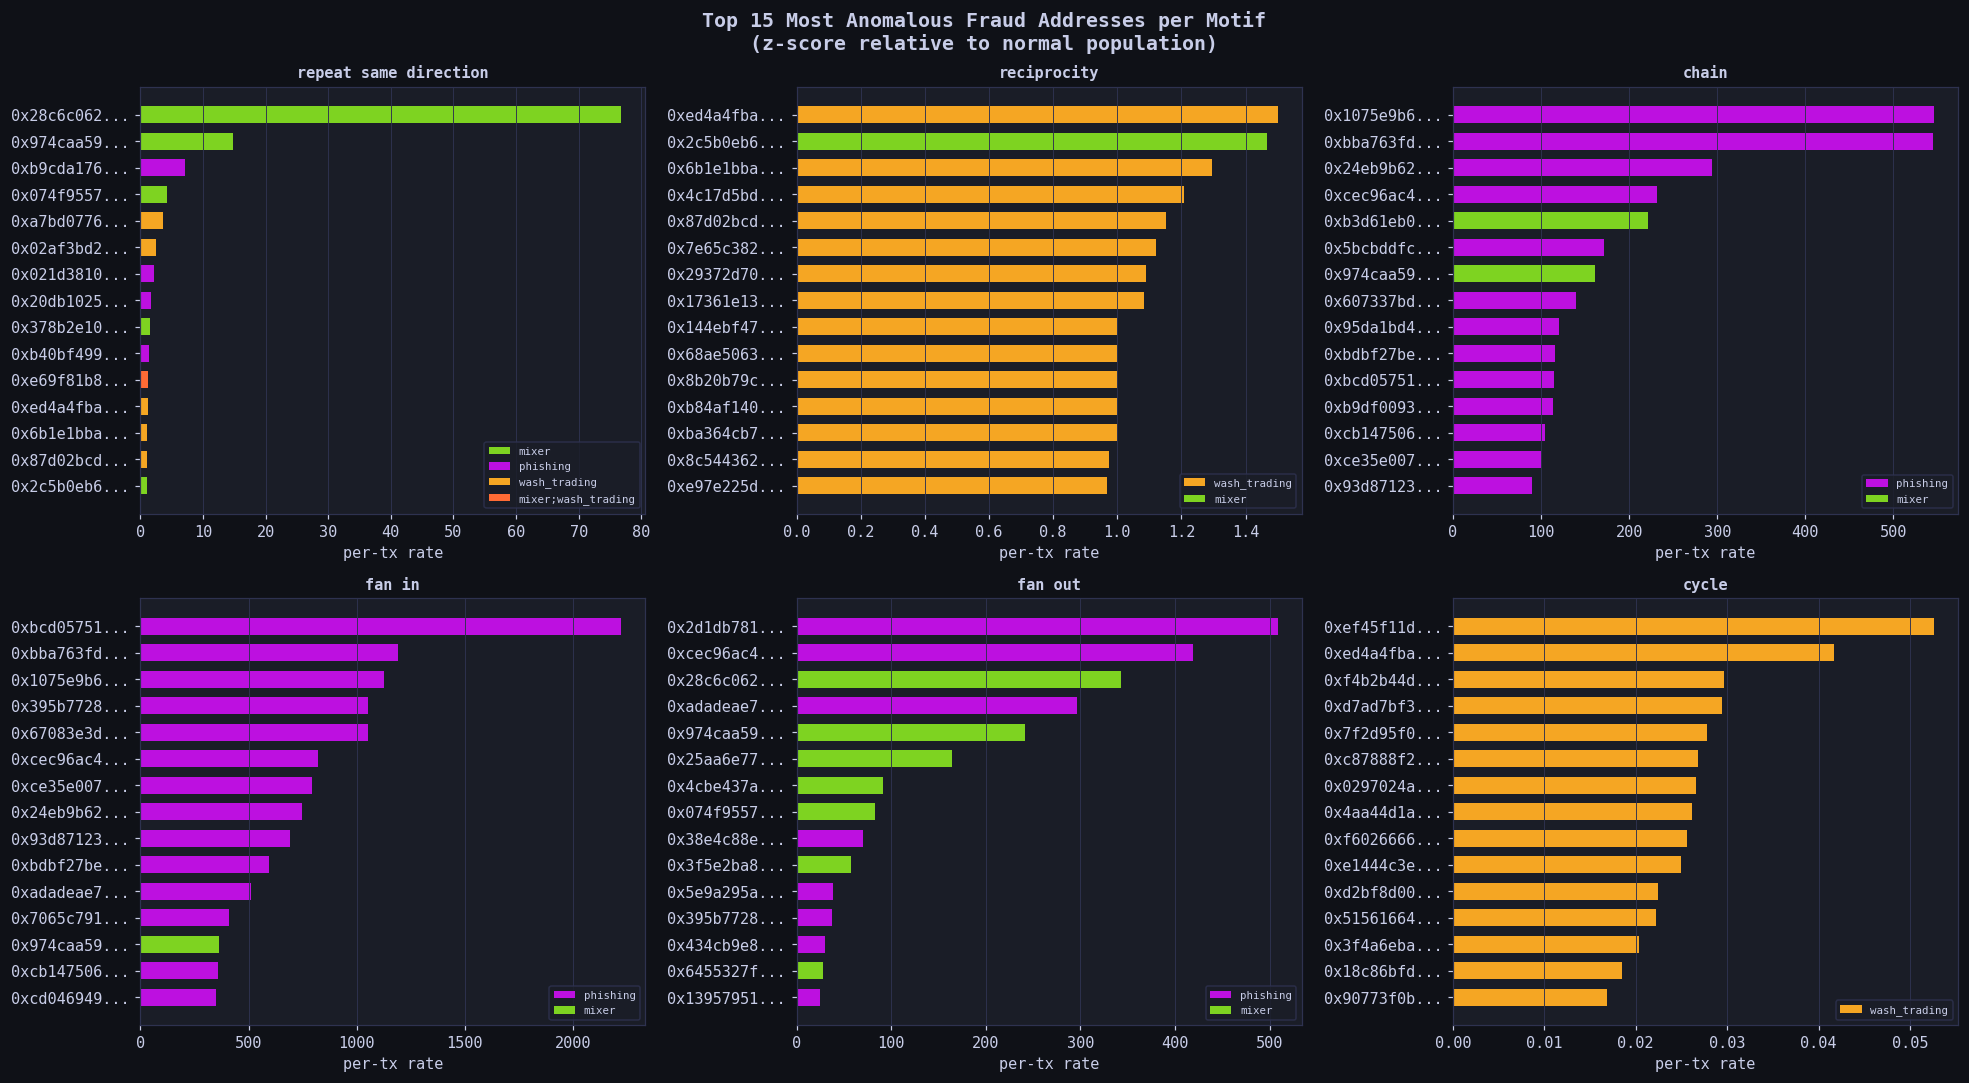

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle("Top 15 Most Anomalous Fraud Addresses per Motif\n(z-score relative to normal population)",
             fontsize=13, fontweight="bold")

for i, col in enumerate(PER_TX_COLS):
    ax = axes[i]
    top = fraud.nlargest(15, col)[["address", "detected_type", col]].copy()
    top["short_addr"] = top["address"].str[:10] + "..."
    bar_colors = [PALETTE.get(t, "#888") for t in top["detected_type"]]
    bars = ax.barh(top["short_addr"], top[col], color=bar_colors, height=0.65)
    ax.set_title(col.replace("_per_tx_1h","").replace("_"," "), fontsize=10, fontweight="bold")
    ax.set_xlabel("per-tx rate")
    ax.invert_yaxis()
    ax.grid(axis="x")

    # colour legend via dummy patches
    from matplotlib.patches import Patch
    seen = top["detected_type"].unique()
    handles = [Patch(facecolor=PALETTE.get(t,"#888"), label=t) for t in seen]
    ax.legend(handles=handles, fontsize=7, loc="lower right",
              facecolor="#1a1d27", edgecolor="#2e3250", labelcolor="#c8cde8")

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

**The z-score table** measures how many standard deviations above the normal-population mean each fraud address sits, on average, for each motif. It answers: *how abnormal are fraud addresses, statistically?*

**The bar charts** show the top 15 most extreme fraud addresses for each motif, coloured by their fraud type. Address labels are truncated for readability.

**Key findings from the z-score table:**

- **Reciprocity: z = 1.76** and **cycle: z = 1.08** — the only two motifs where fraud addresses are meaningfully above the normal mean. These are the statistically anomalous signals.
- **Chain, fan_in, fan_out: z ≈ -0.4** — fraud addresses are actually *below* the normal mean on these three. As seen earlier, normal addresses participate heavily in these common structural motifs, so fraud addresses are not outliers here.
- **Repeat same-direction: z = 0.31** — mildly elevated but not a strong standalone signal.

**Key findings from the bar charts:**

- **Fan_in and chain** are dominated by **phishing** addresses with extreme outlier values (fan_in rates of 2,222 and 1,192 per transaction; chain rates of 546 and 545). These are addresses receiving from thousands of victims within single 1-hour windows — the most extreme cases in the dataset.
- **Reciprocity** top addresses are a mix of **wash_trading** and **mixer** — these are the most actively reciprocating wallets, consistent with coordinated back-and-forth transfers.
- **Repeat same-direction** is topped by a single **mixer** address (`0x28c6c0...`) with a rate of 76.8 — far above the next closest. This one address is a significant outlier and likely a high-volume automated mixer.
- **Fan_out** top addresses are mostly **phishing** (distributing collected funds) with one **mixer** in the mix.
- **Cycle** top addresses are exclusively **wash_trading** with very small absolute values (max 0.05) — confirming that cycle participation is rare even among fraudsters, but when it appears it is almost always wash trading.


## 5. Per-tx Rate Distributions — Fraud vs Normal

In [17]:
df_log = df[PER_TX_COLS + ["label", "detected_type"]].copy()
for c in PER_TX_COLS:
    df_log[c] = np.log1p(df[c])

print(f"{'Feature':45s}  {'Normal mean':>12}  {'Fraud mean':>10}  {'Ratio':>7}")
print("-" * 85)
for c in PER_TX_COLS:
    nm = df_log.loc[df_log["label"]=="normal", c].mean()
    fr = df_log.loc[df_log["label"]=="fraud",  c].mean()
    ratio = fr / (nm + 1e-9)
    tag = "  ***" if ratio > 5 else ("  **" if ratio > 2 else ("  *" if ratio > 1.3 else ""))
    print(f"  {c:43s}  {nm:12.4f}  {fr:10.4f}  {ratio:7.2f}x{tag}")


Feature                                         Normal mean  Fraud mean    Ratio
-------------------------------------------------------------------------------------
  repeat_same_direction_per_tx_1h                    0.0354      0.2524     7.13x  ***
  reciprocity_per_tx_1h                              0.0185      0.2626    14.17x  ***
  chain_per_tx_1h                                    1.6238      1.2817     0.79x
  fan_in_per_tx_1h                                   2.0150      1.3576     0.67x
  fan_out_per_tx_1h                                  1.2597      0.8955     0.71x
  cycle_per_tx_1h                                    0.0000      0.0020    44.37x  ***


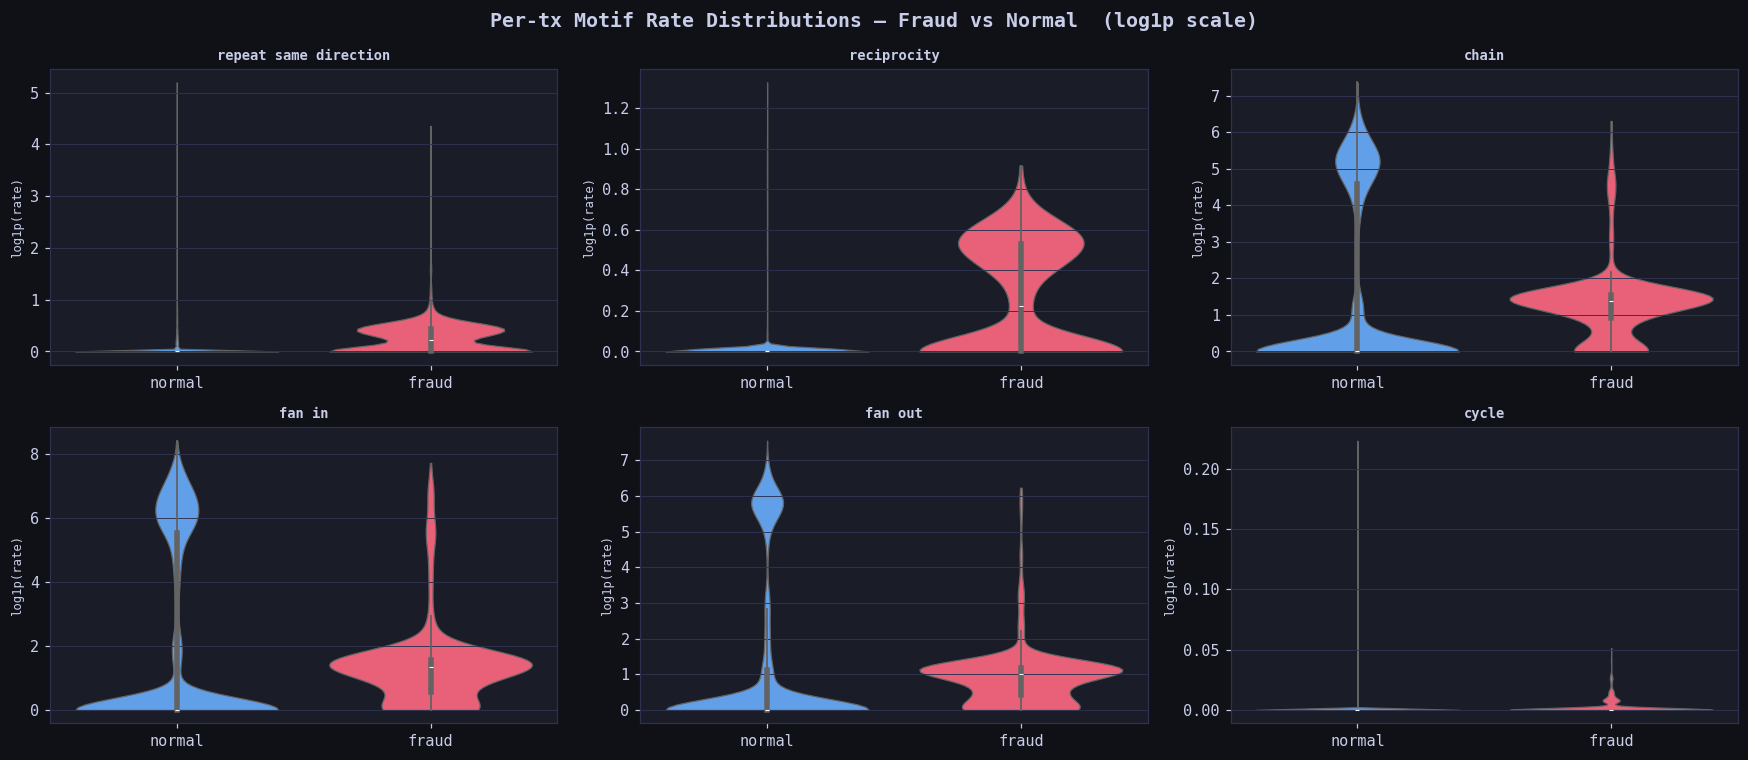

In [18]:
ncols = 3
nrows = -(-len(PER_TX_COLS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*3.5))
axes = axes.flatten()
fig.suptitle("Per-tx Motif Rate Distributions — Fraud vs Normal  (log1p scale)",
             fontsize=13, fontweight="bold")

for i, col in enumerate(PER_TX_COLS):
    ax = axes[i]
    plot_data = df_log[["label", col]].rename(columns={col: "value"})
    sns.violinplot(data=plot_data, x="label", y="value", ax=ax,
                   palette=[PALETTE["normal"], PALETTE["fraud"]],
                   inner="box", linewidth=0.8, cut=0)
    ax.set_title(col.replace("_per_tx_1h","").replace("_"," "), fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("log1p(rate)", fontsize=8)
    ax.grid(axis="y")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

**The ratio table** shows the mean log1p-transformed per-tx rate for normal vs fraud addresses, and the ratio between them. `***` = fraud addresses are >5× higher on average, `**` = >2×, `*` = >1.3×.

**The violin plots** show the full shape of the distribution for each class side by side. The wider a violin at a given height, the more addresses have that value. The inner box shows the interquartile range and median.

**A note on the log1p transform:** because on-chain rates span many orders of magnitude (most addresses have 0, a few have very high values), we apply log(1 + x) before plotting. This compresses extreme outliers so the bulk of the distribution is visible. Values of 0 stay at 0; a rate of 1.0 becomes ~0.69; a rate of 100 becomes ~4.6.

**Key findings per motif:**

- **Reciprocity** — the strongest single discriminator, with fraud addresses averaging **14.2× higher** than normal. The fraud violin is visibly shifted upward. This makes sense: reciprocity (A→B then B→A) is the direct signature of wash trading, and wash trading makes up 86% of fraud cases.

- **Cycle** — even more extreme at **44× higher** for fraud, but from a near-zero baseline. The fraud violin barely lifts off zero either, meaning this motif is extremely rare even for fraud — but when it does appear, it's almost exclusively on fraud addresses. It's a high-precision, low-recall signal.

- **Repeat same direction** — **7× higher** for fraud. Similar logic to reciprocity: coordinated accounts sending the same token back and forth repeatedly in one direction to inflate trading volume.

- **Chain, fan_in, fan_out** — counterintuitively, fraud addresses score **lower** than normal on these three (ratios of 0.67–0.79). This is because the median normal address already participates heavily in these common motifs (chains and fan structures are the natural shape of most Ethereum transactions), while the fraud population is dominated by wash traders who concentrate exclusively on reciprocity and repeat patterns.

**Bottom line:** `reciprocity_per_tx_1h` and `repeat_same_direction_per_tx_1h` are the clearest fraud signals in this feature set when looking at binary normal/fraud. `cycle_per_tx_1h` is a high-precision rare signal. The three structural motifs (chain, fan_in, fan_out) are not useful for binary fraud detection on their own.


### 5b. Per-tx Distributions broken down by fraud type

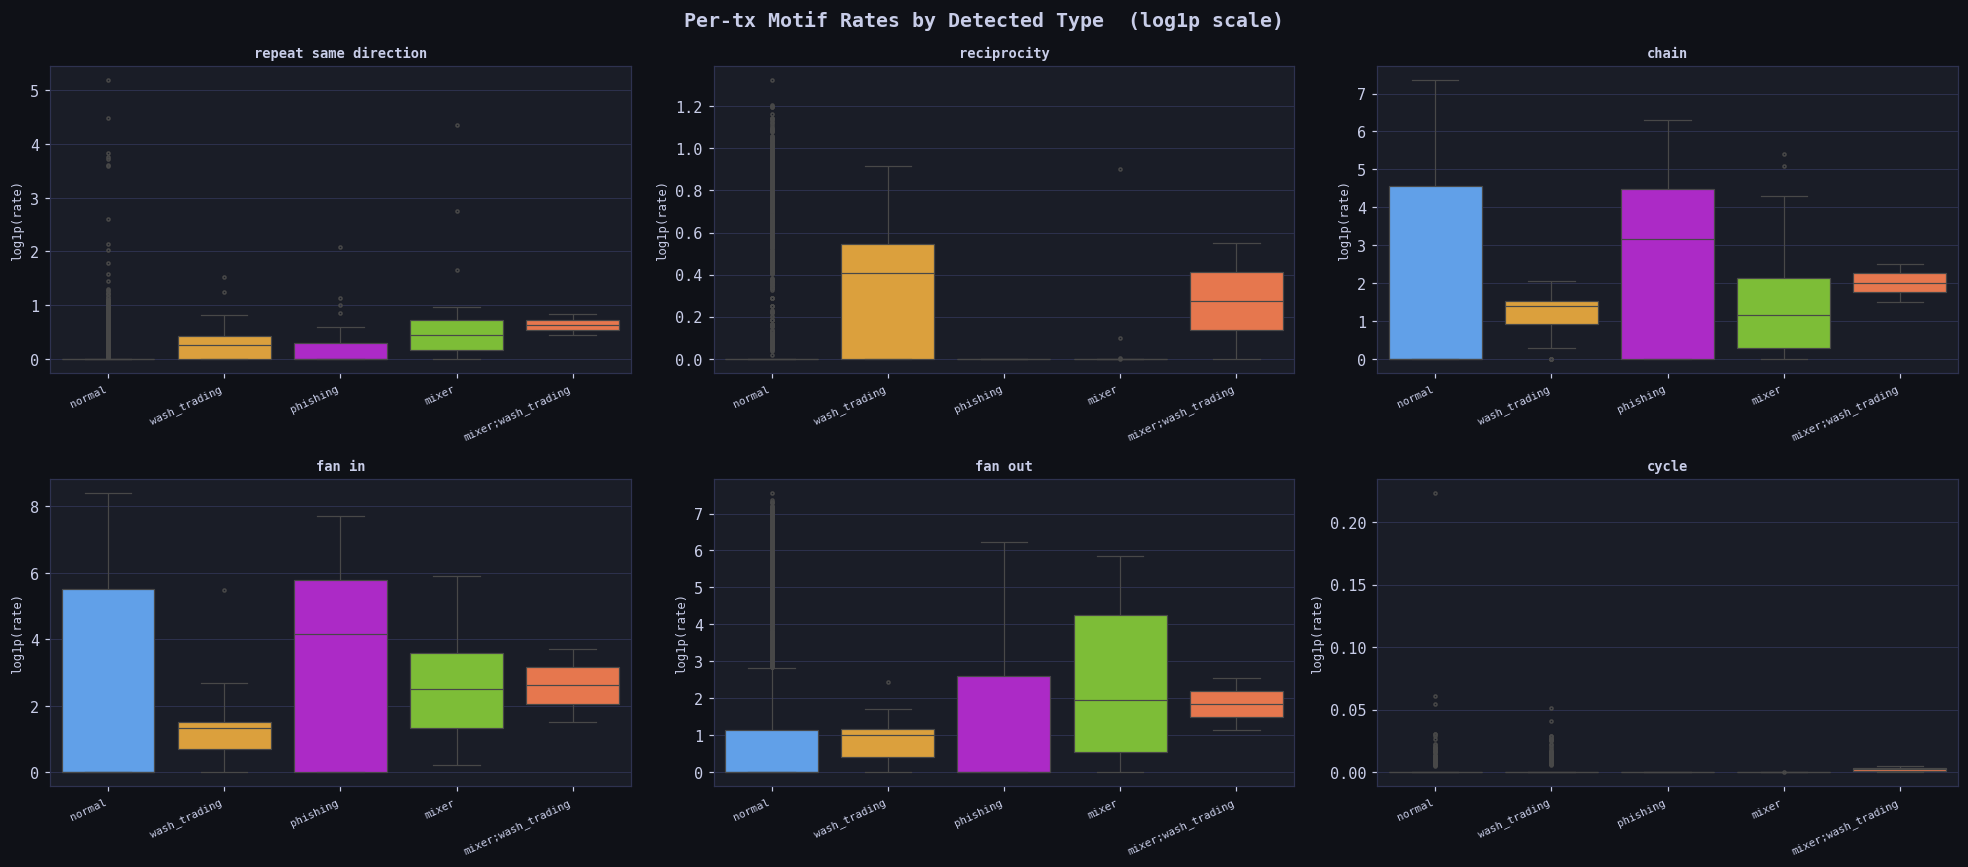

In [19]:
ncols = 3
nrows = -(-len(PER_TX_COLS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4))
axes = axes.flatten()
fig.suptitle("Per-tx Motif Rates by Detected Type  (log1p scale)",
             fontsize=13, fontweight="bold")

order = ["normal", "wash_trading", "phishing", "mixer", "mixer;wash_trading"]
order = [o for o in order if o in df["detected_type"].unique()]
pal   = [PALETTE.get(o, "#888") for o in order]

for i, col in enumerate(PER_TX_COLS):
    ax = axes[i]
    plot_data = df_log[["detected_type", col]].rename(columns={col: "value"})
    sns.boxplot(data=plot_data, x="detected_type", y="value", ax=ax,
                order=order, palette=pal, linewidth=0.8, fliersize=2)
    ax.set_title(col.replace("_per_tx_1h","").replace("_"," "), fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("log1p(rate)", fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=7)
    ax.grid(axis="y")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

**Box plots** show the median (centre line), interquartile range (box), whiskers (1.5× IQR), and outliers (dots) for each detected type separately. This is the fine-grained version of the previous violins — instead of collapsing all fraud into one group, we can now see how each fraud type differs.

**Key findings:**

- **Reciprocity** — `wash_trading` sits clearly above all other types, as expected. `mixer` and `phishing` have near-zero reciprocity, confirming this motif is almost exclusive to wash trading.

- **Fan_in** — `phishing` has by far the highest median and the widest spread. This is the clearest motif-level signature of phishing: victims send funds in from many directions. `mixer` also shows elevated fan_in (consistent with the consolidation phase of mixing).

- **Chain** — `phishing` again dominates. After collecting funds, phishing wallets route them quickly down a forwarding chain, which explains the very high chain rate we saw in Section 3.

- **Repeat same direction** — elevated across all fraud types but highest for wash trading and mixer+wash_trading. This confirms that repeated directional transfers between fixed pairs is a cross-cutting fraud signal, not unique to one type.

- **Fan_out** — `mixer` shows elevated fan_out relative to other types (redistributing funds to many destinations), but the separation from normal is not very strong. This motif is less discriminative on its own.

- **Cycle** — near-zero across all types including fraud. Very rare but when present it tends to be fraud. The box for wash_trading sits slightly above normal, consistent with circular trading schemes.

**Overall:** each fraud type has at least one motif where it clearly separates from normal, and the separation directions differ between types. This validates that multi-class detection is feasible with these features.


## 6. Community Fingerprints — Motif Rates per Community & Label

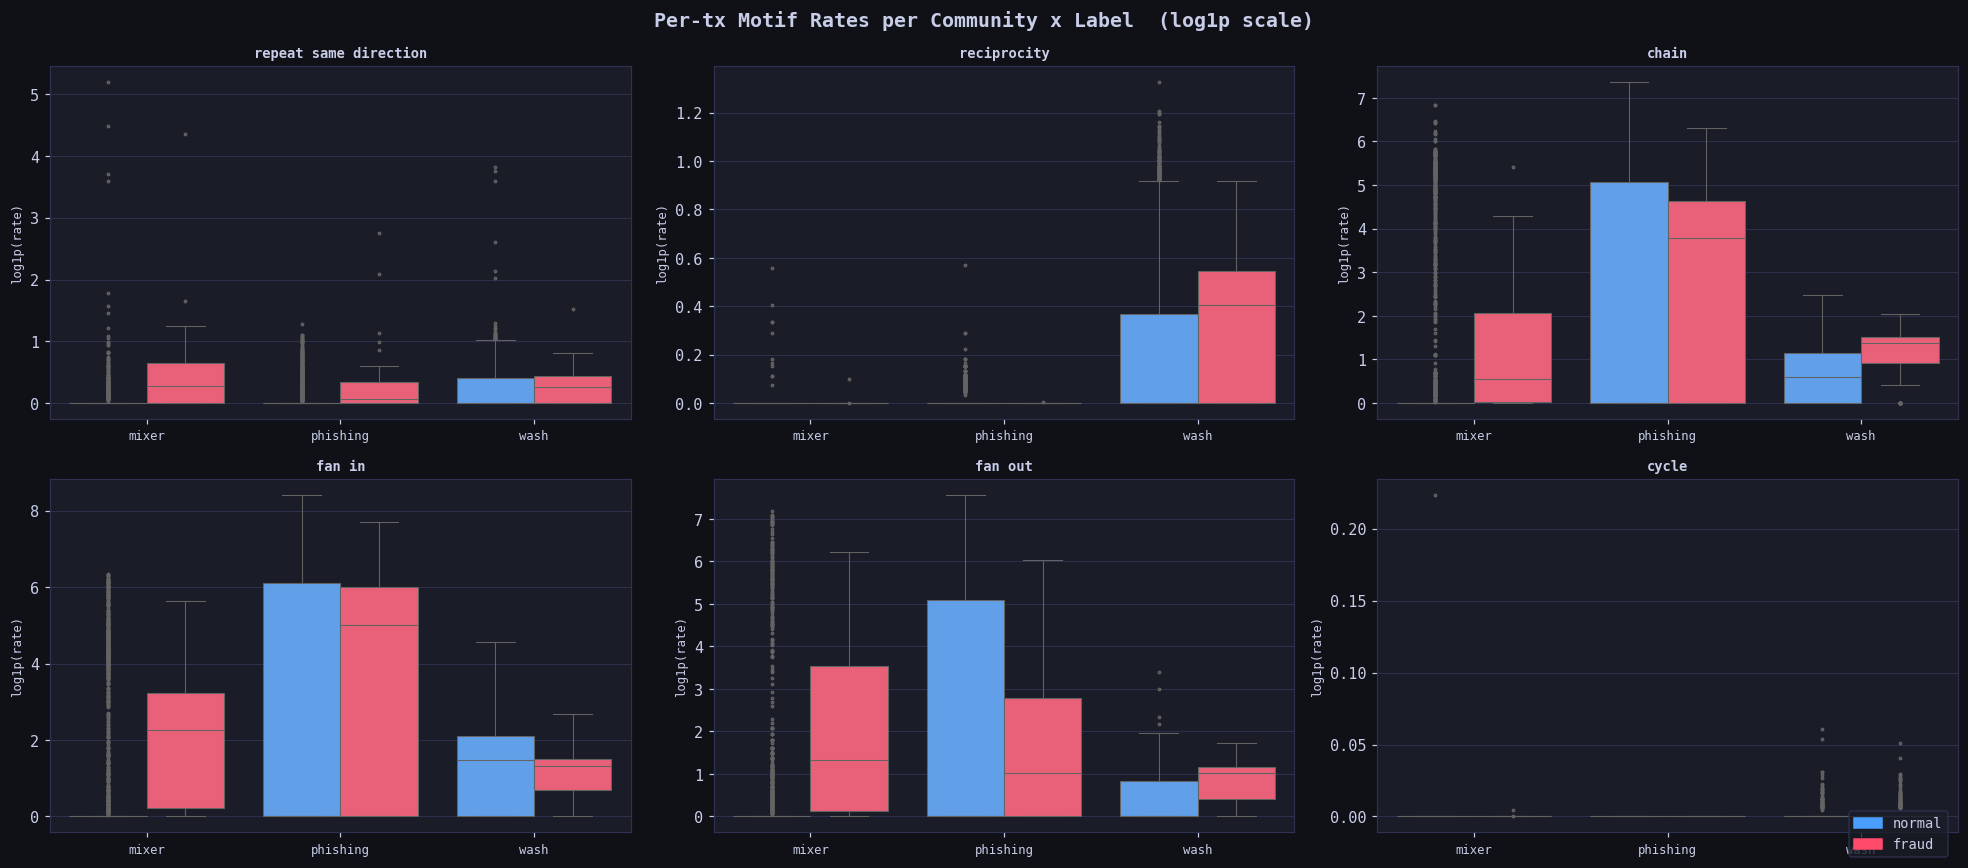

In [20]:
ncols = 3
nrows = -(-len(PER_TX_COLS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4))
axes = axes.flatten()
fig.suptitle("Per-tx Motif Rates per Community x Label  (log1p scale)",
             fontsize=13, fontweight="bold")

df_plot = df[PER_TX_COLS + ["community","label"]].copy()
for c in PER_TX_COLS:
    df_plot[c] = np.log1p(df_plot[c])

comm_order = sorted(df["community"].unique())

for i, col in enumerate(PER_TX_COLS):
    ax = axes[i]
    plot_data = df_plot[["community","label",col]].rename(columns={col:"value"})
    sns.boxplot(data=plot_data, x="community", y="value", hue="label",
                ax=ax, order=comm_order,
                palette=[PALETTE["normal"], PALETTE["fraud"]],
                linewidth=0.7, fliersize=1.5)
    ax.set_title(col.replace("_per_tx_1h","").replace("_"," "), fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("log1p(rate)", fontsize=8)
    ax.set_xticklabels([c.split("_")[0] for c in comm_order], fontsize=8)
    ax.grid(axis="y")
    if ax.get_legend(): ax.get_legend().remove()

handles = [plt.Rectangle((0,0),1,1,color=PALETTE["normal"],label="normal"),
           plt.Rectangle((0,0),1,1,color=PALETTE["fraud"], label="fraud")]
fig.legend(handles=handles, loc="lower right", bbox_to_anchor=(0.99,0.01),
           fontsize=9, facecolor="#1a1d27", edgecolor="#2e3250", labelcolor="#c8cde8")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### What these graphs show and what they tell us

Each subplot is one per-tx motif rate. For each community, two side-by-side boxes compare normal (blue) vs fraud (red) addresses on that motif. This lets us see whether the **fraud signal is consistent across communities or concentrated in one**.

**Key findings:**

- **Reciprocity** — the fraud vs normal gap is almost entirely driven by the `wash_trading` community. In `mixer` and `phishing` communities, the fraud box for reciprocity is close to the normal box, because the fraud in those communities is mixer/phishing type, not wash-trading. This confirms that features are community-dependent: the same motif means different things depending on which community you are in.

- **Fan_in** — the separation is clearest in `phishing_390`, where the fraud (red) box sits noticeably higher than normal. This is consistent with Section 5b: fan_in is the phishing signature, and phishing fraud lives mostly in the phishing community.

- **Chain** — also elevated for fraud in `phishing_390` specifically, again driven by phishing's fund-forwarding behaviour.

- **Repeat same direction** — elevated for fraud in `wash_trading_846`, the community with the highest fraud density. The separation is cleaner here than in the other two communities.

- **Mixer community** — fraud addresses in `mixer_242` show moderate elevation across several motifs (fan_in, chain) but the sample is very small (28 fraud addresses), so the box plots are noisy.

**Overall takeaway from Section 6:** the communities are not interchangeable. Each one has a different dominant fraud type, and that fraud type's motif signature is most visible within its respective community. This suggests that **community membership is a useful contextual variable** — passing it as a categorical node feature to the GNN (or using it to define separate graph partitions) could help the model distinguish between, say, a high fan_in score in a phishing community (suspicious) vs the same score in the wash_trading community (not as unusual).


## 7. Summary

| Finding | Detail |
|---|---|
| **Wash trading dominates fraud (86%)** | 458 of 533 fraud addresses; communities are single-type — Infomap isolated each fraud strategy cleanly |
| **Community fraud rates differ sharply** | wash_trading_846 is 16.3% fraud vs <0.5% in the other two — Infomap successfully isolated the wash-trading cluster |
| **Each fraud type has a distinct motif fingerprint** | Phishing → extreme fan_in + chain. Wash trading → high reciprocity + repeat. Mixer → spread across fan_in, chain, fan_out |
| **Normal addresses have near-zero motif participation** | Median of 0 on all per-tx rates — normal users don't create recurring graph patterns within 1-hour windows |
| **Reciprocity and cycle are the cleanest binary fraud signals** | 14× and 44× higher for fraud vs normal respectively |
| **Chain, fan_in, fan_out are not useful as binary signals** | Normal addresses use these motifs heavily too — they only discriminate when broken down by fraud type |
| **54 near-redundant feature pairs (|r| ≥ 0.95)** | Count and value features are almost perfectly correlated — pruning to per-tx rates + counts only is advisable |
| **Fraud drives 75% of ETH volume despite being 2% of addresses** | Two mixer addresses alone account for the bulk — fraud is concentrated in a small number of high-activity nodes |
| **Community context matters** | The same motif rate has different implications in different communities — worth encoding community ID as a node feature |
